# 🤝 Innovation Proximity Analysis

In Economic Complexity, **Proximity** measures the probability that a country is good at producing one thing given that it is already good at producing another. 

Specifically, $Proximity(i, j)$ is the probability that a country has a Comparative Advantage in field $i$ given it has one in field $j$, or vice versa (we take the minimum of these two probabilities to make it symmetric).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ecomplexity import ecomplexity, proximity
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data
We will focus on the **Production (P)** dimension for the year **2023** to keep the analysis simple and relevant.

In [13]:
# Load mapping files
fields = pd.read_parquet('data/fields.parquet')

# Load output data
outputs = pd.read_parquet('data/outputs.parquet')

# Filter for Production dimension in 2023
data_2023 = outputs[(outputs['Period'] == 2023) & (outputs['Dimension'] == 'P')].copy()
print(f"Selected {len(data_2023):,} rows for Production in 2023")

Selected 164,642 rows for Production in 2023


## 2. Calculate RCA (Revealed Comparative Advantage)
We use the `py-ecomplexity` library to calculate the RCA for each country and field. RCA > 1 means the country is specialized in that field.

In [14]:
trade_cols = {'time': 'Period', 'loc': 'Unit', 'prod': 'Field ID', 'val': 'Outputs (Fractional)'}
complexity_results = ecomplexity(data_2023[trade_cols.values()], trade_cols)

# Binary matrix (Mcp): 1 if RCA > 1, else 0
mcp = complexity_results.pivot(index='Unit', columns='Field ID', values='rca')
mcp = (mcp > 1).astype(int)

print(f"RCA Matrix shape: {mcp.shape} (Countries x Fields)")

2023
Percentage of pairs compared that meet log-supermodularity condition: 40.25%
RCA Matrix shape: (191, 862) (Countries x Fields)


## 3. Calculate Proximity Matrix
The proximity between two fields is the conditional probability of co-occurrence. 
We use the `proximity` function from the `ecomplexity` library, which implements the standard formula: 
$\phi_{ij} = \frac{\sum_c M_{ci} M_{cj}}{\max(k_i, k_j)}$

In [15]:
# Calculate Proximity using library function
prox_long = proximity(complexity_results, trade_cols)

# Pivot the long format into a square matrix for visualization
proximity_matrix = prox_long.pivot(index='Field ID_1', columns='Field ID_2', values='proximity')

print("✅ Proximity data received and pivoted into matrix")
display(proximity_matrix.iloc[:5, :5])

2023
✅ Proximity data received and pivoted into matrix


Field ID_2,P - 0101,P - 0102,P - 0103,P - 0104,P - 0105
Field ID_1,,,,,
P - 0101,1.000000,0.183673,0.250000,0.137931,0.195122
P - 0102,0.183673,1.000000,0.306122,0.428571,0.469388
P - 0103,0.250000,0.306122,1.000000,0.137931,0.268293
P - 0104,0.137931,0.428571,0.137931,1.000000,0.292683
P - 0105,0.195122,0.469388,0.268293,0.292683,1.000000


## 4. Visualize Proximity
We can visualize a subset of the proximity matrix to see how similar certain fields are. 
We will pick the first 15 fields for clarity.

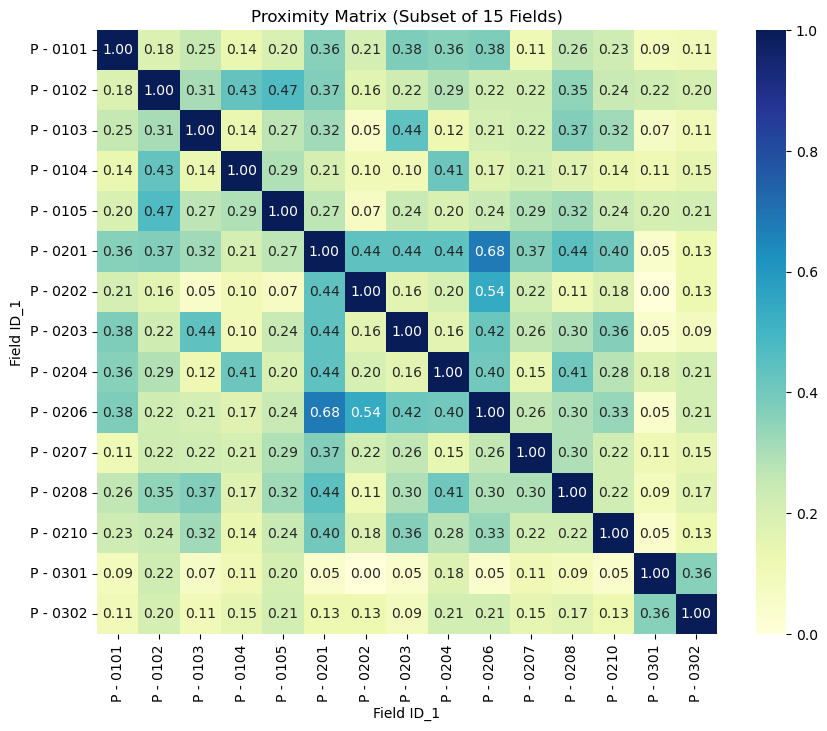

In [16]:
subset_fields = proximity_matrix.index[:15]
subset_matrix = proximity_matrix.loc[subset_fields, subset_fields]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_matrix, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Proximity Matrix (Subset of 15 Fields)")
plt.show()

## 5. Most Similar Fields
Which fields are the most linked to each other?

In [17]:
# Use the long format directly for finding strongest links
pairs = prox_long[prox_long['Field ID_1'] != prox_long['Field ID_2']].copy()
pairs.columns = ['Period', 'Field A', 'Field B', 'Proximity']

# Merge with field names for readability
pairs = pairs.merge(fields[['Field ID', 'Field Name']], left_on='Field A', right_on='Field ID')
pairs = pairs.rename(columns={'Field Name': 'Name A'}).drop('Field ID', axis=1)
pairs = pairs.merge(fields[['Field ID', 'Field Name']], left_on='Field B', right_on='Field ID')
pairs = pairs.rename(columns={'Field Name': 'Name B'}).drop('Field ID', axis=1)

print("Top 10 strongest links between fields:")
display(pairs.sort_values(by='Proximity', ascending=False).head(10))

Top 10 strongest links between fields:


,Period,Field A,Field B,Proximity,Name A,Name B
380148,2023,P - 6110,P - 6104,0.825000,Knit Sweaters,Women's Knit Suits
385309,2023,P - 6104,P - 6110,0.825000,Women's Knit Suits,Knit Sweaters
393934,2023,P - 6203,P - 6204,0.813953,Men's Woven Suits,Women's Woven Suits
393073,2023,P - 6204,P - 6203,0.813953,Women's Woven Suits,Men's Woven Suits
384462,2023,P - 6203,P - 6109,0.800000,Men's Woven Suits,Knit T-Shirts and Vests
393063,2023,P - 6109,P - 6203,0.800000,Knit T-Shirts and Vests,Men's Woven Suits
380157,2023,P - 6203,P - 6104,0.790698,Men's Woven Suits,Women's Knit Suits
393936,2023,P - 6206,P - 6204,0.790698,Women's Woven Blouses,Women's Woven Suits
385323,2023,P - 6203,P - 6110,0.790698,Men's Woven Suits,Knit Sweaters
395657,2023,P - 6204,P - 6206,0.790698,Women's Woven Suits,Women's Woven Blouses


## 6. Product Clustering
By applying hierarchical clustering to the proximity matrix, we can identify "communities" of products that require similar capabilities. 

### Clustered Heatmap
We can also visualize the clusters using a clustermap, which reorders the rows and columns to reveal the block-diagonal structure of product communities.

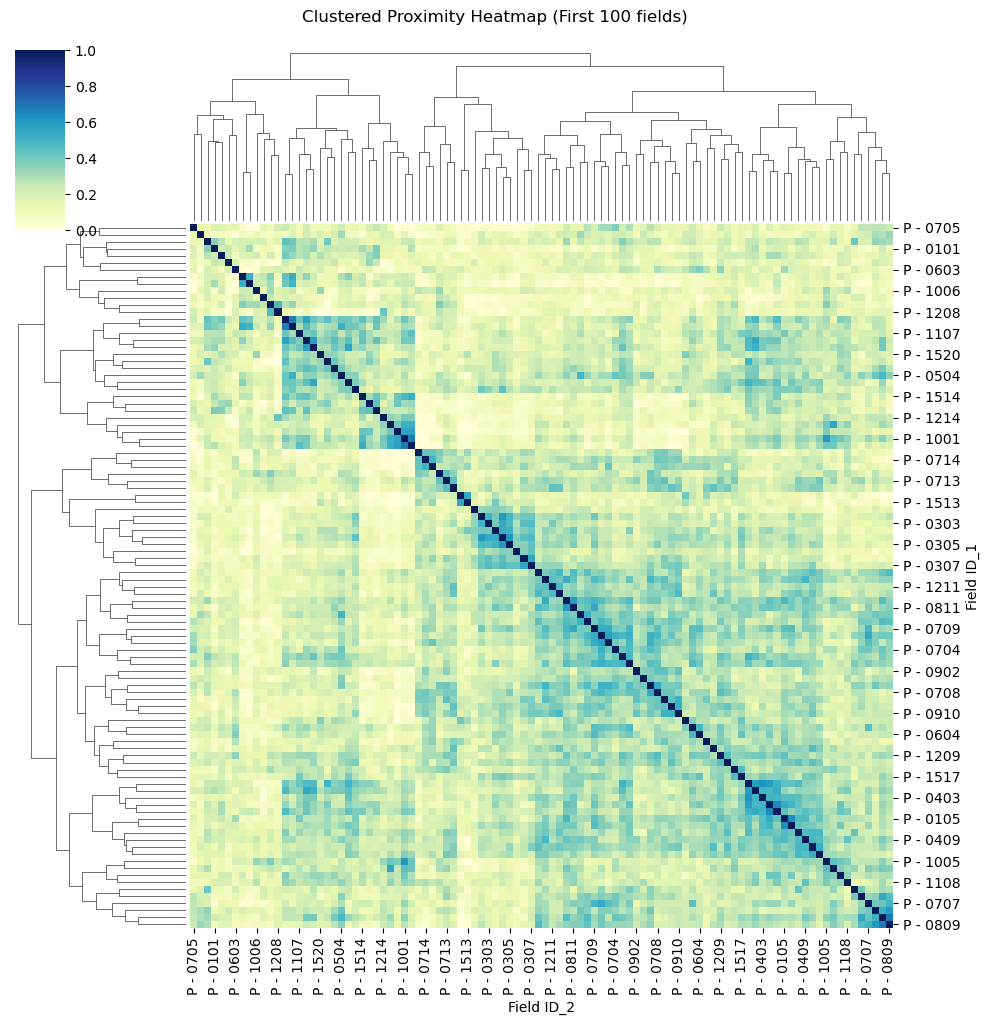

In [21]:
# Visualize a subset with clustermap to see the groups clearly
subset_size = 100
subset_matrix = proximity_matrix.iloc[:subset_size, :subset_size]

sns.clustermap(subset_matrix.fillna(0), 
               method='complete', 
               cmap='YlGnBu', 
               figsize=(10, 10), 
               annot=False, 
               fmt=".2f")
plt.suptitle(f'Clustered Proximity Heatmap (First {subset_size} fields)', y=1.02)
plt.show()